# Brightspot Detection - Denoising

### Haar Cascade -> Detect Eye as ROI

In [1]:
import cv2
import matplotlib.pyplot as plt
import os
import rawpy
import numpy as np

In [84]:
eye_cascade = cv2.CascadeClassifier(r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\notebooks\haarcascade_eye.xml')

img_path = r"C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Dataset Preliminary\buat cc\Validasi CC 2.dng"

Memproses gambar: C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Dataset Preliminary\buat cc\Validasi CC 2.dng
Ukuran gambar asli: (4624, 3468, 3)


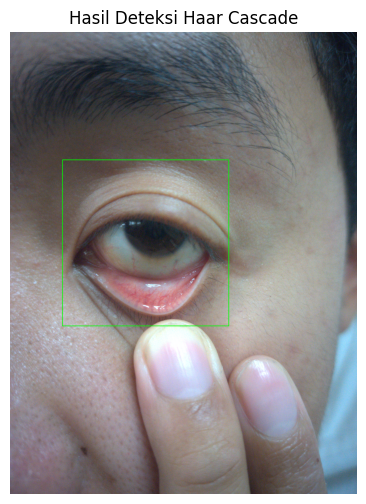

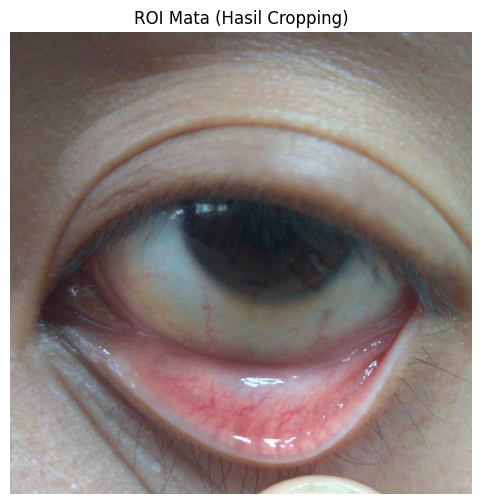

Ukuran Gambar setelah di-Crop : (1662, 1662, 3)
Tipe Data ROI Mata: uint8, Rentang Nilai: [0, 255]


In [85]:
if not os.path.exists(img_path):
    print(f"Error: Gambar '{img_path}' tidak ditemukan di direktori saat ini.")
else:
    print(f"Memproses gambar: {img_path}")
    
    with rawpy.imread(img_path) as raw:
        # dimiripin nanti sama penggunaan di color correction
        img_rgb = raw.postprocess(use_camera_wb=True, exp_shift=1.0)

    img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

    # 1. Konversi ke Grayscale (Haar Cascade WAJIB menggunakan citra abu-abu untuk deteksi)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 2. Deteksi Mata
    # Fungsi ini akan mereturn array berisi [x, y, width, height] dari kotak pembatas
    eyes = eye_cascade.detectMultiScale(
        gray, 
        scaleFactor=1.1,  # Menentukan seberapa besar gambar diperkecil setiap iterasi (1.1 = 10%)
        minNeighbors=3,   # Menentukan jumlah kotak tetangga agar area divalidasi sebagai mata
        minSize=(50, 50)  # Ukuran minimum objek. Diperbesar agar tidak salah deteksi noise kecil
    )
    
    # 3. Proses Hasil Deteksi dan Cropping
    if len(eyes) > 0:
        # Kita looping (meskipun biasanya kita hanya butuh 1 mata untuk dianalisis)
        for (x, y, w, h) in eyes:
            
            # --- VISUALISASI BOUNDING BOX ---
            # Salin gambar asli agar gambar original tidak tertimpa garis kotak
            img_dengan_kotak = img.copy()
            # Gambar kotak hijau (0, 255, 0) dengan ketebalan garis 5
            cv2.rectangle(img_dengan_kotak, (x, y), (x+w, y+h), (0, 255, 0), 5)
            img_dengan_kotak = cv2.cvtColor(img_dengan_kotak, cv2.COLOR_BGR2RGB)  # Konversi ke RGB untuk Matplotlib
            print(f"Ukuran gambar asli: {img.shape}")
            plt.figure(figsize=(8, 6))
            plt.imshow(img_dengan_kotak)
            plt.title("Hasil Deteksi Haar Cascade")
            plt.axis('off')
            plt.show()
            
            # --- PROSES CROPPING (ROI) ---
            # Memotong gambar menggunakan Numpy Slicing: array[startY:endY, startX:endX]
            roi_mata = img[y:y+h, x:x+w]
            roi_mata_rgb = cv2.cvtColor(roi_mata, cv2.COLOR_BGR2RGB)  # Konversi ke RGB untuk Matplotlib - (LAST RGB)
            plt.figure(figsize=(8, 6))
            plt.imshow(roi_mata_rgb)
            plt.title("ROI Mata (Hasil Cropping)")
            plt.axis('off')
            plt.show()

            roi_mata_bgr = roi_mata
            print(f"Ukuran Gambar setelah di-Crop : {roi_mata.shape}")
            print(f"Tipe Data ROI Mata: {roi_mata.dtype}, Rentang Nilai: [{roi_mata.min()}, {roi_mata.max()}]")
            
            # Kita 'break' karena kita hanya ingin memproses mata pertama yang terdeteksi
            break
            
    else:
        print("Mata tidak terdeteksi oleh Haar Cascade.")
        print("Saran: Coba turunkan nilai 'minNeighbors' (misal: 3) atau 'scaleFactor' (misal: 1.05).")

### Brightspot Detection - Inpainting

#### 1 - Convert HSV

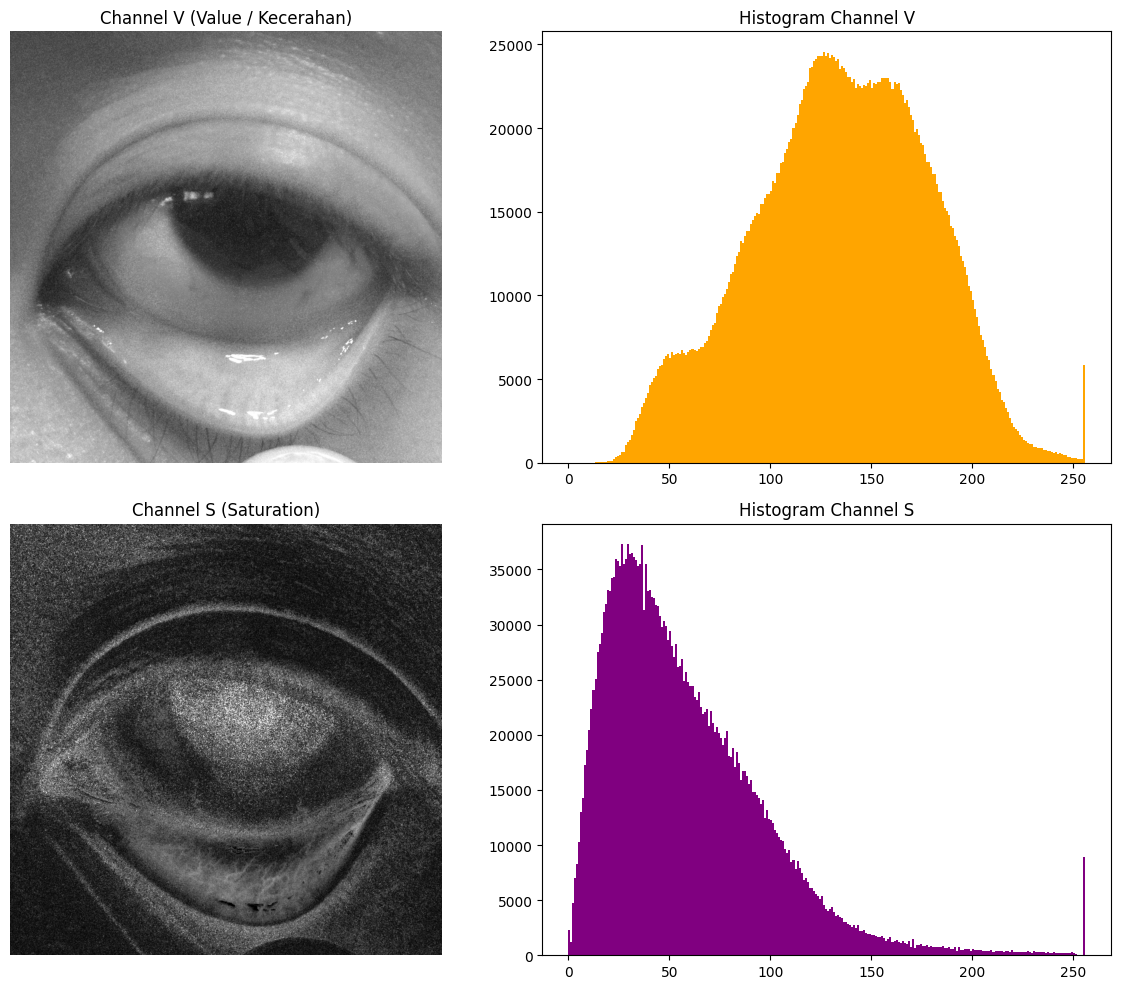

In [86]:
hsv = cv2.cvtColor(roi_mata_bgr, cv2.COLOR_BGR2HSV)
v_channel = hsv[:, :, 2]
s_channel = hsv[:, :, 1]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Visualisasi Channel V
axes[0, 0].imshow(v_channel, cmap='gray')
axes[0, 0].set_title('Channel V (Value / Kecerahan)')
axes[0, 0].axis('off')

# Histogram Channel V
axes[0, 1].hist(v_channel.ravel(), bins=256, range=[0,256], color='orange')
axes[0, 1].set_title('Histogram Channel V')

# Visualisasi Channel S (Area putih/pantulan cahaya biasanya memiliki S yang rendah/gelap)
axes[1, 0].imshow(s_channel, cmap='gray')
axes[1, 0].set_title('Channel S (Saturation)')
axes[1, 0].axis('off')

# Histogram Channel S
axes[1, 1].hist(s_channel.ravel(), bins=256, range=[0,256], color='purple')
axes[1, 1].set_title('Histogram Channel S')

plt.tight_layout()
plt.show()

#### 2 - Masking

Batas Threshold V: 220.0
Batas Maksimum S: 30


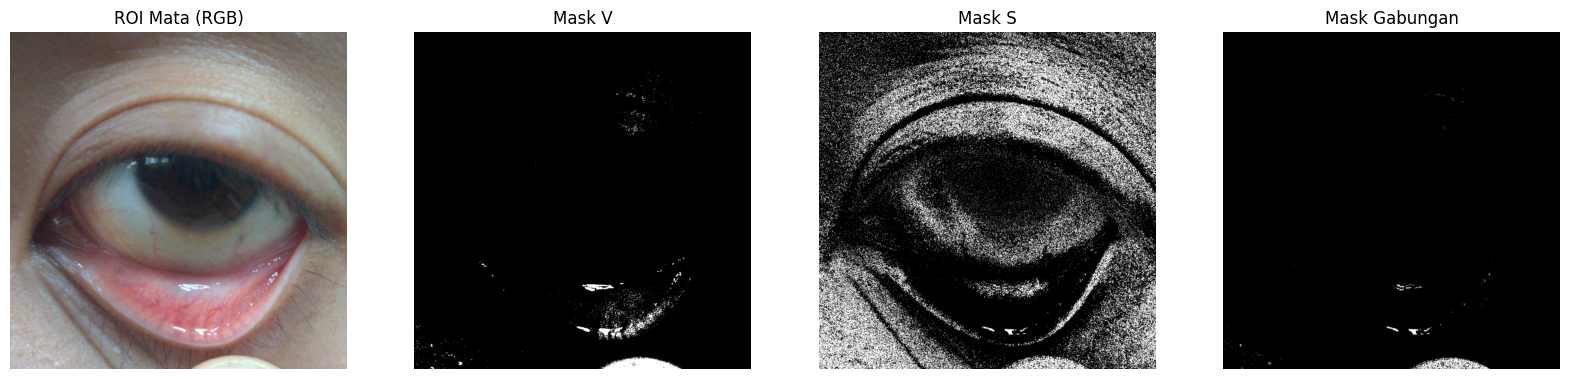

In [87]:
v_percentile = 97  # tune
s_max = 30         # tune

v_threshold = np.percentile(v_channel, v_percentile)
v_threshold = max(220, v_threshold) # minimal 220

print(f"Batas Threshold V: {v_threshold:.1f}")
print(f"Batas Maksimum S: {s_max}")

mask_v = (v_channel >= v_threshold).astype(np.uint8) * 255
mask_s = (s_channel <= s_max).astype(np.uint8) * 255
mask_combined = cv2.bitwise_and(mask_v, mask_s)

# Visualisasi
fig, axes = plt.subplots(1, 4, figsize=(20, 10))

axes[0].imshow(roi_mata_rgb)
axes[0].set_title('ROI Mata (RGB)')
axes[0].axis('off')

axes[1].imshow(mask_v, cmap='gray')
axes[1].set_title('Mask V')
axes[1].axis('off')

axes[2].imshow(mask_s, cmap='gray')
axes[2].set_title('Mask S')
axes[2].axis('off')

axes[3].imshow(mask_combined, cmap='gray')
axes[3].set_title('Mask Gabungan')
axes[3].axis('off')

plt.show()

#### 3 - Finishing (Morphological Cleaning)

Jumlah pixel dalam mask setelah dilasi: 7639290
Jumlah Pixel Area Terbesar yang terdeteksi sebagai brightspot: 255


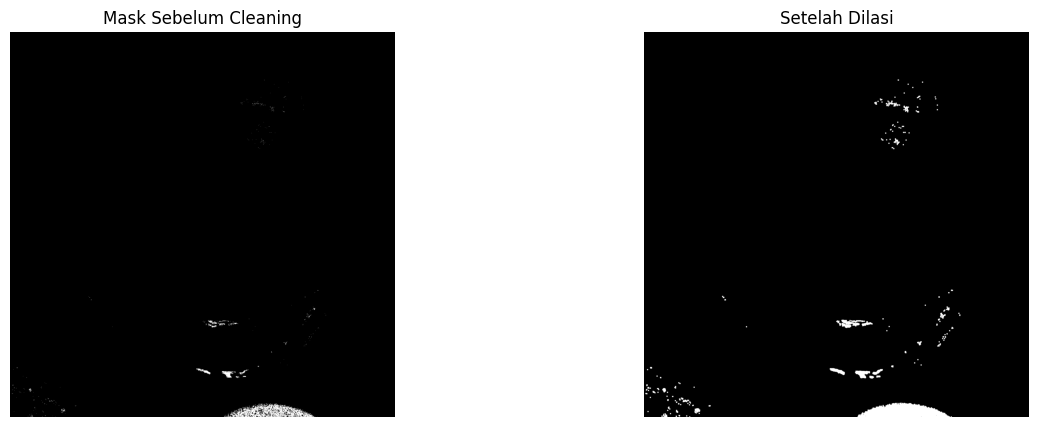

In [88]:
dilation_iter = 2

# Dilasi untuk memperlebar area brightspot (agar inpaint lebih rapi)
kernel_dilate = np.ones((3, 3), np.uint8)
mask_dilated = cv2.dilate(mask_combined, kernel_dilate, iterations=dilation_iter)

# Visualisasi perubahan mask
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(mask_combined, cmap='gray')
axes[0].set_title('Mask Sebelum Cleaning')
axes[0].axis('off')

axes[1].imshow(mask_dilated, cmap='gray')
axes[1].set_title('Setelah Dilasi')
axes[1].axis('off')

print(f"Jumlah pixel dalam mask setelah dilasi: {np.sum(mask_dilated)}")
print(f"Jumlah Pixel Area Terbesar yang terdeteksi sebagai brightspot: {np.max(mask_dilated[mask_dilated > 0])}")

plt.show()


Total brightspot yang dipertahankan: 22


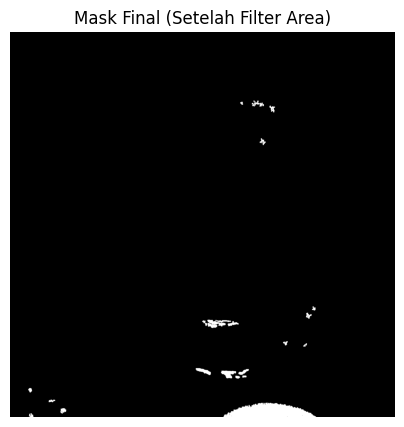

In [92]:
min_area = 100     #tune
max_area = 50000   #tune

num_labels, labels_cc, stats, centroids = cv2.connectedComponentsWithStats(mask_dilated)
mask_final = np.zeros_like(mask_dilated)

valid_count = 0
for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if min_area <= area <= max_area:
        mask_final[labels_cc == i] = 255
        valid_count += 1

print(f"\nTotal brightspot yang dipertahankan: {valid_count}")

# Tampilkan mask final
plt.figure(figsize=(5,5))
plt.imshow(mask_final, cmap='gray')
plt.title('Mask Final (Setelah Filter Area)')
plt.axis('off')
plt.show()

#### 6- Inpainting

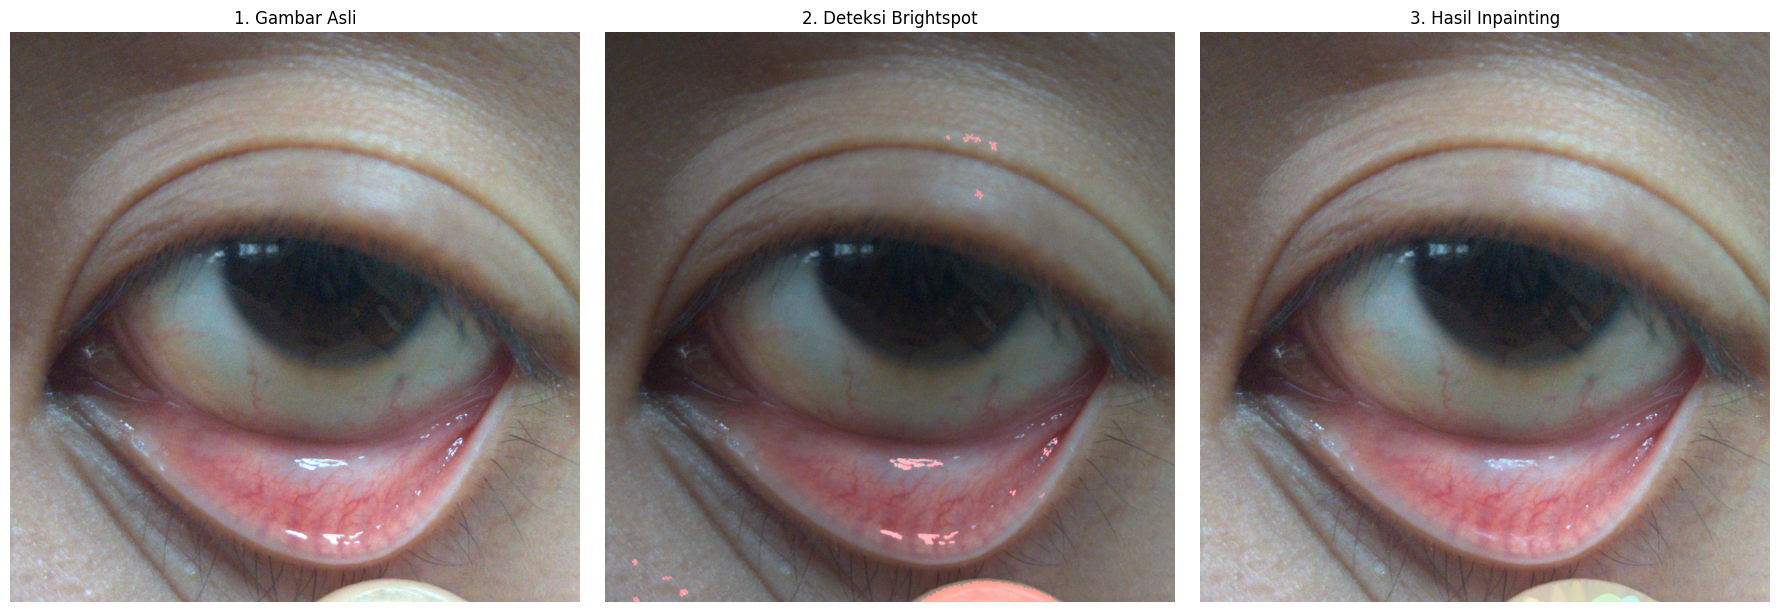

In [93]:
roi_bersih = cv2.inpaint(roi_mata_bgr, mask_final, inpaintRadius=5, flags=cv2.INPAINT_TELEA)

overlay_rgb = cv2.cvtColor(roi_mata_bgr, cv2.COLOR_BGR2RGB)
red_canvas = np.zeros_like(overlay_rgb)
red_canvas[:] = (255, 0, 0)
colored_mask = cv2.bitwise_and(red_canvas, red_canvas, mask=mask_final)
blended = cv2.addWeighted(overlay_rgb, 0.75, colored_mask, 0.6, 0)

roi_bersih_rgb = cv2.cvtColor(roi_bersih, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(roi_mata_rgb)
axes[0].set_title("1. Gambar Asli")
axes[0].axis('off')

axes[1].imshow(blended)
axes[1].set_title("2. Deteksi Brightspot")
axes[1].axis('off')

axes[2].imshow(roi_bersih_rgb)
axes[2].set_title("3. Hasil Inpainting")
axes[2].axis('off')

plt.tight_layout()
plt.show()